# Car Price Prediction with Machine Learning
### Objective: Predict the selling price of used cars based on brand, age, mileage, fuel type, and transmission.

In [2]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
#Load Data

df = pd.read_csv("CAR_DETAILS_FROM_CAR_DEKHO.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [4]:
print("Shape:", df.shape)
df.info()

print("\nNull values per column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (4340, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB

Null values per column:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

Duplicate rows: 763


In [5]:
# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

# Check unique values in categorical columns for inconsistencies
for col in ['fuel', 'seller_type', 'transmission', 'owner']:
    print(f"\n{col}: {df[col].unique()}")

Shape after removing duplicates: (3577, 8)

fuel: ['Petrol' 'Diesel' 'CNG' 'LPG' 'Electric']

seller_type: ['Individual' 'Dealer' 'Trustmark Dealer']

transmission: ['Manual' 'Automatic']

owner: ['First Owner' 'Second Owner' 'Fourth & Above Owner' 'Third Owner'
 'Test Drive Car']


In [6]:
# Standardize casing/whitespace
cat_cols = ['fuel', 'seller_type', 'transmission', 'owner']
for col in cat_cols:
    df[col] = df[col].str.strip().str.title()

df[cat_cols].nunique()

fuel            5
seller_type     3
transmission    2
owner           5
dtype: int64

**Observation:** The dataset has no missing values. After removing duplicates and standardizing category text, we have clean categorical fields for `fuel`, `seller_type`, `transmission`, and `owner`.

### Feature Engineering

In [7]:
current_year = 2024
df['car_age'] = current_year - df['year']
df[['name', 'year', 'car_age']].head()

,name,year,car_age
0,Maruti 800 AC,2007,17
1,Maruti Wagon R LXI Minor,2007,17
2,Hyundai Verna 1.6 SX,2012,12
3,Datsun RediGO T Option,2017,7
4,Honda Amaze VX i-DTEC,2014,10


In [8]:
df['brand'] = df['name'].apply(lambda x: x.split()[0])

print("Number of unique brands:", df['brand'].nunique())
df['brand'].value_counts().head(10)

Number of unique brands: 29


brand
Maruti        1072
Hyundai        637
Mahindra       328
Tata           308
Ford           220
Honda          216
Toyota         170
Chevrolet      151
Renault        110
Volkswagen      93
Name: count, dtype: int64

In [9]:
# Drop columns which are not needed.

df_model = df.drop(columns=['name', 'year'])
df_model.head()

,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age,brand
0,60000,70000,Petrol,Individual,Manual,First Owner,17,Maruti
1,135000,50000,Petrol,Individual,Manual,First Owner,17,Maruti
2,600000,100000,Diesel,Individual,Manual,First Owner,12,Hyundai
3,250000,46000,Petrol,Individual,Manual,First Owner,7,Datsun
4,450000,141000,Diesel,Individual,Manual,Second Owner,10,Honda


**Observation:** `car_age` was derived from the manufacturing year, and `brand` was extracted from the car name (first word). The original `name` and `year` columns are no longer needed after this transformation.

### EDA

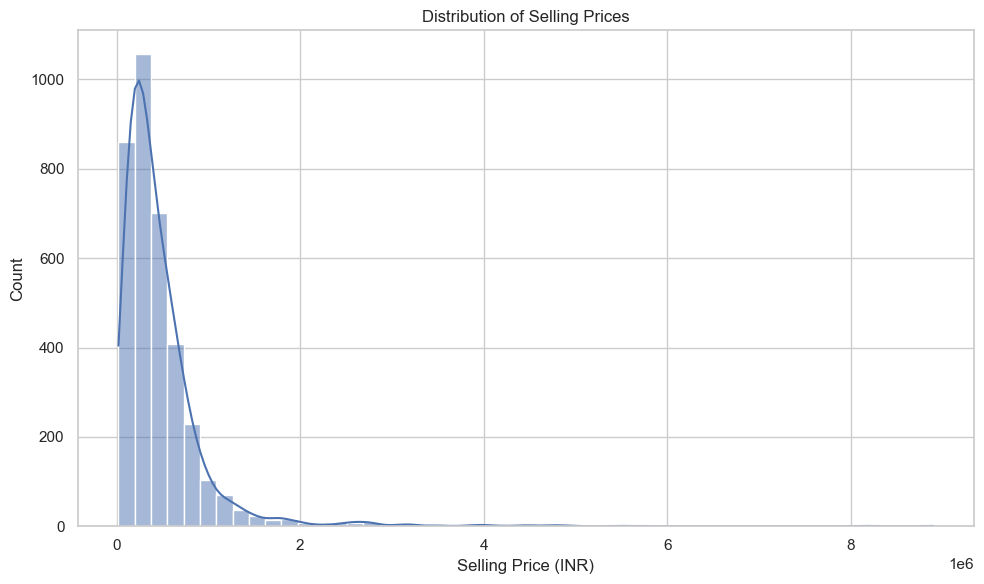

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(df_model['selling_price'], bins=50, kde=True)
plt.title('Distribution of Selling Prices')
plt.xlabel('Selling Price (INR)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Observation:** Selling prices are heavily right-skewed — most cars sell for relatively low prices, with a long tail of expensive vehicles. This suggests tree-based models may handle the data better than plain linear regression.

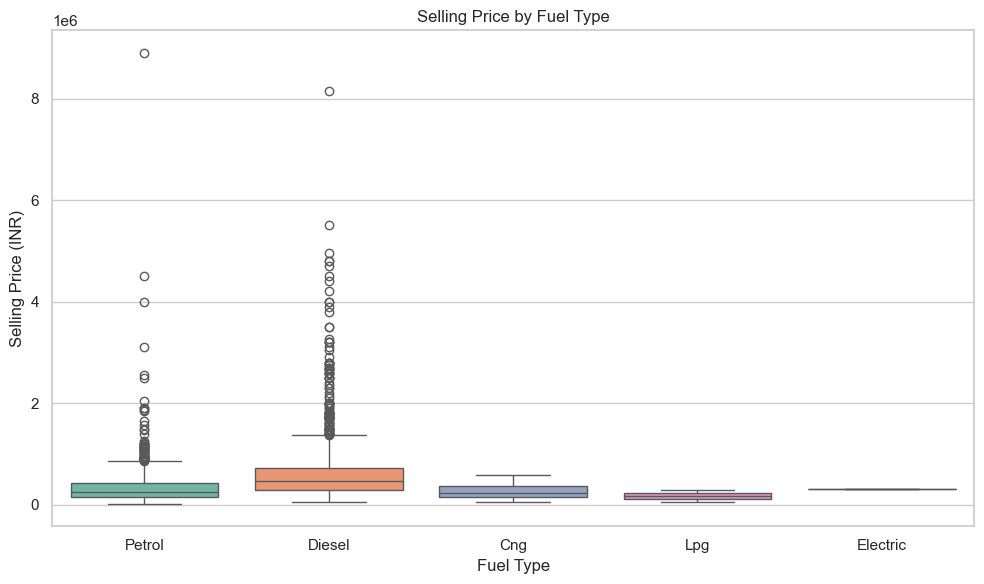

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='fuel', y='selling_price', data=df_model, hue='fuel', palette='Set2', legend=False)
plt.title('Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price (INR)')
plt.tight_layout()
plt.show()

**Observation:** Diesel cars tend to have a higher median selling price than Petrol or CNG cars, likely reflecting their association with larger, higher-end vehicles.

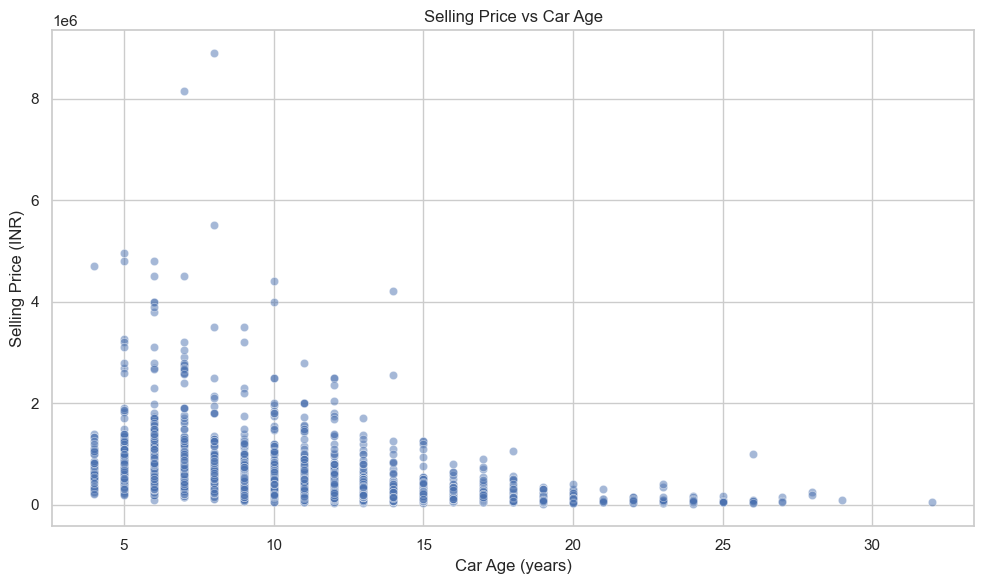

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='car_age', y='selling_price', data=df_model, alpha=0.5)
plt.title('Selling Price vs Car Age')
plt.xlabel('Car Age (years)')
plt.ylabel('Selling Price (INR)')
plt.tight_layout()
plt.show()

**Observation:** There's a clear negative relationship between car age and selling price — newer cars sell for significantly more, and prices drop sharply within the first few years before leveling off.

In [13]:
# One-Hot Encoding for nominal categorical variables
df_encoded = pd.get_dummies(
    df_model,
    columns=['fuel', 'seller_type', 'transmission', 'brand', 'owner'],
    drop_first=True
)

print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Shape after encoding: (3577, 42)


,selling_price,km_driven,car_age,fuel_Diesel,fuel_Electric,fuel_Lpg,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,...,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,60000,70000,17,False,False,False,True,True,False,True,...,False,False,False,False,False,False,False,False,False,False
1,135000,50000,17,False,False,False,True,True,False,True,...,False,False,False,False,False,False,False,False,False,False
2,600000,100000,12,True,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
3,250000,46000,7,False,False,False,True,True,False,True,...,False,False,False,False,False,False,False,False,False,False
4,450000,141000,10,True,False,False,False,True,False,True,...,False,False,False,False,False,False,False,True,False,False


**Observation:** One-Hot Encoding was used for all categorical columns (including `owner`) since there's no strict linear ordering assumption we want to force on the model — letting tree-based models learn the relationship freely tends to work better than an arbitrary ordinal mapping.

### Correaltion Heatmap

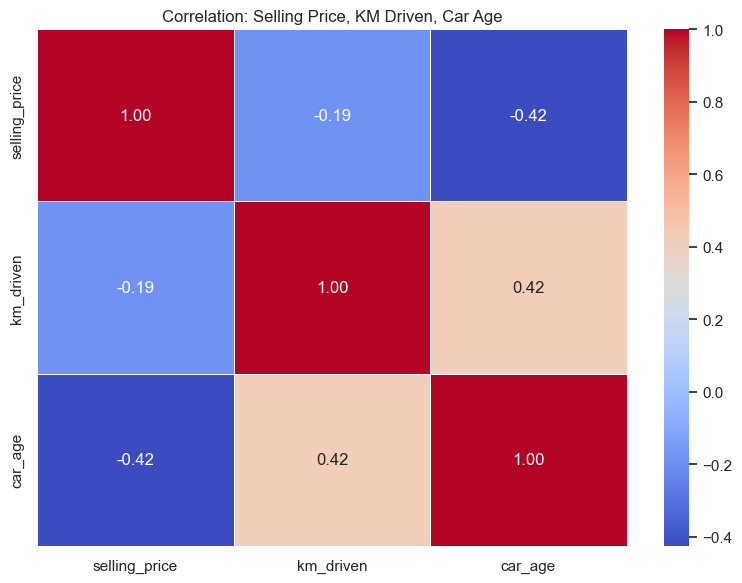

In [14]:
plt.figure(figsize=(8, 6))
numeric_cols = ['selling_price', 'km_driven', 'car_age']
corr_matrix = df_encoded[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation: Selling Price, KM Driven, Car Age')
plt.tight_layout()
plt.show()

**Observation:** `car_age` shows a strong negative correlation with selling price, confirming it as a key predictor. `km_driven` also correlates negatively but more weakly, suggesting age matters more than mileage alone.

### Train-Test-Split

In [15]:
X = df_encoded.drop(columns=['selling_price'])
y = df_encoded['selling_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (2861, 41)
Test shape: (716, 41)


### Linear Regression

In [16]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

### Random Forest Regressor

In [17]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

### Gradient Boosting Regressor

In [18]:
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

### Evaluate Models

In [19]:
def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2 Score': r2}

results = pd.DataFrame([
    evaluate(y_test, y_pred_lr, 'Linear Regression'),
    evaluate(y_test, y_pred_rf, 'Random Forest'),
    evaluate(y_test, y_pred_gb, 'Gradient Boosting')
])

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,180194.987022,385606.086098,0.538415
1,Random Forest,158168.892834,363731.492523,0.589299
2,Gradient Boosting,157530.555402,377057.030765,0.558655


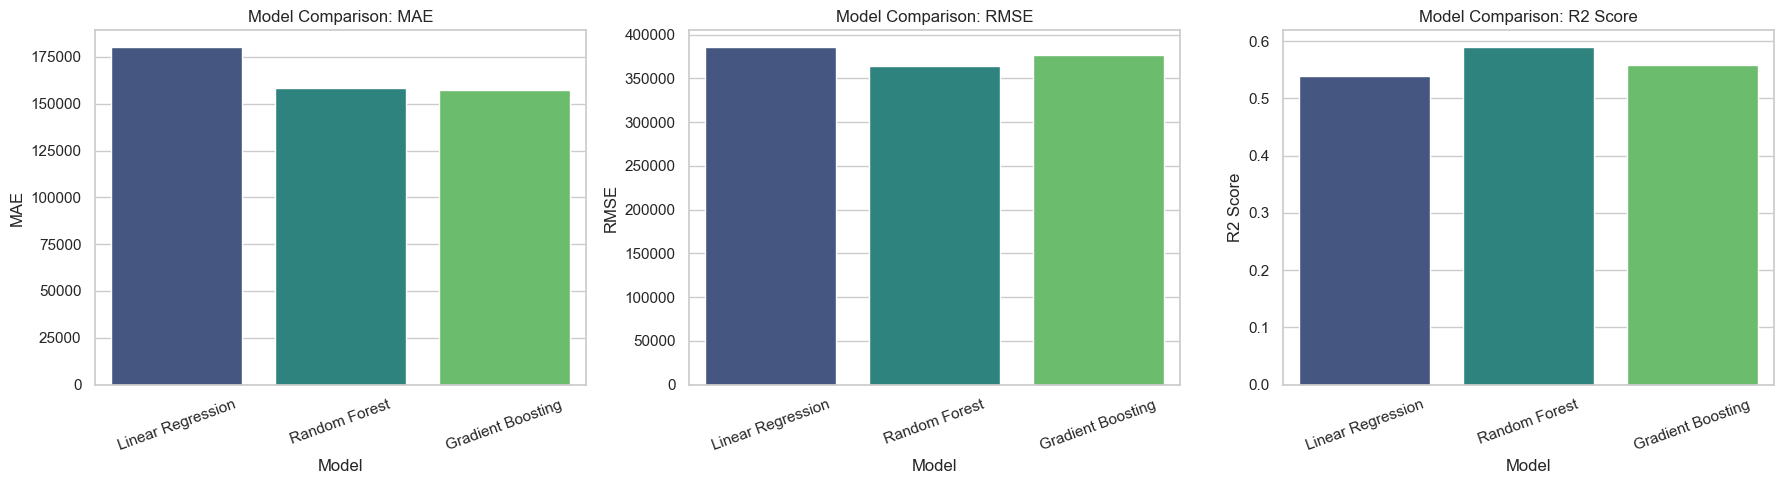

In [20]:
# Bar Chart: Compare Model Performance

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2 Score']):
    sns.barplot(x='Model', y=metric, data=results, hue='Model', palette='viridis', legend=False, ax=ax)
    ax.set_title(f'Model Comparison: {metric}')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

**Observation:** Tree-based models (Random Forest and Gradient Boosting) typically outperform plain Linear Regression on this dataset, since car prices follow non-linear patterns (e.g. steep depreciation curves) that linear models can't fully capture.

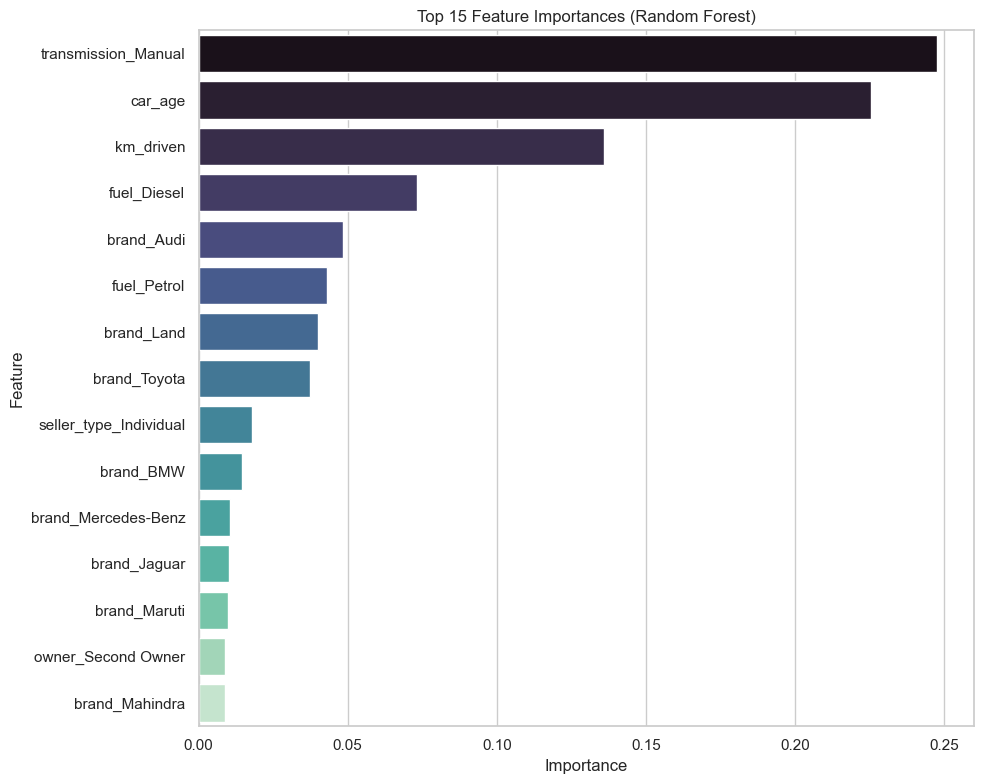

In [21]:
# Feature Importance Chart

best_model = rf_model
best_model_name = "Random Forest"

importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
top_features = importances.head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_features.values, y=top_features.index, hue=top_features.index, palette='mako', legend=False)
plt.title(f'Top 15 Feature Importances ({best_model_name})')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**Observation:** `transmission_Manual` and `car_age` are the two most influential features, followed by `km_driven`. This is a bit unusual — transmission type typically shouldn't outweigh car age — which may be because manual cars dominate the dataset (imbalanced categories) or because transmission correlates strongly with car segment/price tier. `fuel_Diesel` and specific brands like Audi, Land (Rover), Toyota, and BMW also contribute meaningfully, reflecting how premium/luxury brands and diesel variants tend to hold higher resale value.

## Conclusion
- **Model comparison results:**

| Model | MAE | RMSE | R² Score |
|---|---|---|---|
| Linear Regression | 180,194.99 | 385,606.09 | 0.538 |
| Random Forest | 158,168.89 | 363,731.49 | **0.589** |
| Gradient Boosting | 157,530.56 | 377,057.03 | 0.559 |

- **Random Forest performed best overall**, achieving the highest R² score (0.589) and lowest RMSE, meaning it explains ~59% of the variance in selling price and has the smallest average prediction error among the three models.
- Gradient Boosting had the lowest MAE by a narrow margin, but Random Forest generalized better overall (better RMSE and R²).
- Linear Regression underperformed both ensemble methods, confirming that car price depreciation follows a non-linear pattern that tree-based models capture more effectively.
- The most important predictors were `car_age`, `km_driven`, and `transmission`, along with fuel type and specific luxury brands (Audi, BMW, Land Rover) — matching the trends seen earlier in the EDA scatter and box plots.
- **Limitation:** An R² of ~0.59 indicates the model captures general trends but leaves notable unexplained variance — likely due to missing features like engine capacity, car condition, or specific model/variant trim, which aren't present in this dataset.